In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from nltk.tokenize import word_tokenize
import os
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import MWETokenizer
from nltk.corpus import wordnet
from wordcloud import WordCloud
from collections import Counter
from sklearn.feature_extraction.text import TfidfVectorizer
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei']  # Windows 用微软雅黑
plt.rcParams['axes.unicode_minus'] = False  # 防止负号也变乱码

## 数据集说明
本数据集来源于 Kaggle，包含 1412 条心理健康相关文本，共 4 列：
- `text`：用户发布的原始文本内容
- `Explanations`：提取自 text 的核心表达片段，去除主语等结构性语言后保留的情感核心内容
- `labels`：心理健康维度标签（0-5）

| 标签 | 英文 | 含义 | 样本数 |
|------|------|------|--------|
| 0 | Intellectual | 智识层面（认知、学习、思维） | 153 |
| 1 | Vocational | 职业层面（工作、事业压力） | 149 |
| 2 | Spiritual | 精神层面（人生意义、信仰） | 189 |
| 3 | Physical | 身体层面（健康、身体症状） | 295 |
| 4 | Social | 社交层面（人际关系） | 405 |
| 5 | Emotional | 情感层面（情绪状态） | 221 |。 Stress（压力） |

In [45]:
#读取数据
df = pd.read_csv('dataset.csv')
print(df.shape)
print(df.dtypes)

(1412, 4)
Unnamed: 0       int64
text            object
Explanations    object
labels           int64
dtype: object


In [46]:
# 集中处理空值
print("=== 空值检查 ===")
print(df.isnull().sum())  # 一次性看所有列的空值

=== 空值检查 ===
Unnamed: 0      0
text            0
Explanations    0
labels          0
dtype: int64


labels
0    153
1    149
2    189
3    295
4    405
5    221
Name: count, dtype: int64


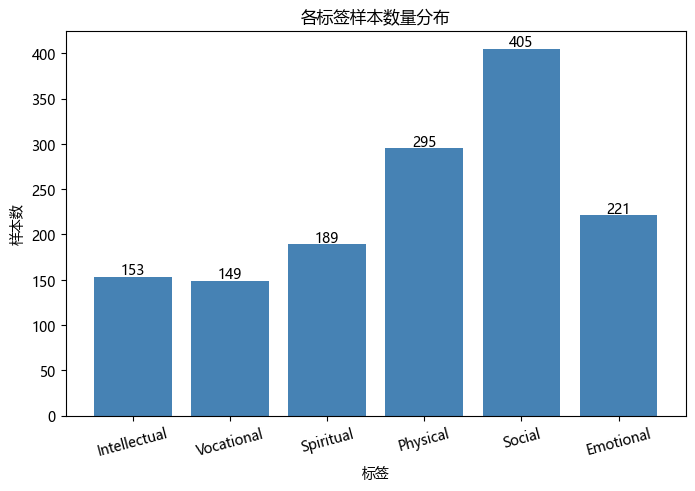

In [63]:
#标签分布可视化
label_counts = df['labels'].value_counts().sort_index()
print(label_counts)
plt.figure(figsize=(8, 5))
plt.bar(label_counts.index, label_counts.values, color='steelblue')
plt.title('各标签样本数量分布')
plt.xticks(range(6), ['Intellectual', 'Vocational', 'Spiritual', 
                       'Physical', 'Social', 'Emotional'], rotation=15)
plt.xlabel('标签')
plt.ylabel('样本数')
for i, v in enumerate(label_counts.values):
    plt.text(i, v + 3, str(v), ha='center')
plt.savefig('charts/01_label.png', dpi=150, bbox_inches='tight')
plt.show()

数据清洗

In [48]:
stop_words = set(stopwords.words('english'))
# 额外添加数据中常见但无意义的词
stop_words.update(['im', 'ive', 'ill', 'id', 'youre', 'hes', 'shes', 'its',                    
'dont', 'doesnt', 'didnt', 'cant', 'wont', 'wouldnt',                    
'couldnt', 'shouldnt', 'isnt', 'arent', 'wasnt', 'werent',                   
'got', 'get', 'getting', 'go', 'going', 'went', 'make', 'making',                   
'like', 'just', 'really', 'now', 'still', 'even', 'also', 'well','this',                   
# 疑问/功能词（信息量低）    
'what', 'how', 'when', 'where', 'why', 'which', 'who', 'whom',    
'about', 'much', 'many', 'any', 'some', 'such', 'like', 'just',        
# 程度/频率词（太泛）    
'always', 'never', 'ever', 'sometimes', 'often', 'constantly',    
'really', 'quite', 'pretty', 'very', 'too', 'so',        
# 时间/数量词（上下文相关）    
'time', 'day', 'days', 'year', 'years', 'month', 'months', 'week',    
'today', 'yesterday', 'tomorrow', 'ago', 'since', 'last', 'next',    
'long', 'short', 'little', 'lot', 'many', 'more', 'most',        
# 动作/状态虚词    
'feel', 'feeling', 'feels', 'felt',  # 保留特定搭配如 'feel alone'    
'think', 'thinking', 'thought', 'thoughts',    
'know', 'want', 'need', 'keep', 'try', 'trying', 'start', 'started',    
'see', 'look', 'put', 'come', 'go', 'went', 'get', 'got',    
'make', 'making', 'take', 'give', 'leave', 'stay', 'live',    
'end', 'point', 'way', 'thing', 'things', 'something', 'anything',    
'everything', 'nothing', 'one', 'everyone', 'someone', 'anyone',    
'back', 'away', 'down', 'up', 'around', 'out', 'over',        
# 状态词（太通用）    
'good', 'bad', 'hard', 'easy', 'fine', 'okay', 'better', 'worse',    
'new', 'old', 'long', 'short', 'high', 'low', 'big', 'small',    
'much', 'more', 'most', 'many', 'lot', 'little',        
# 连词/介词（如果还有残留）    
'though', 'however', 'nevertheless', 'meanwhile',])

In [49]:
def clean_text(series, stop_words):
 # 统一小写
    cleaned = series.str.lower()
    # 去标点
    cleaned = cleaned.str.replace(r'[^\w\s]', '', regex=True)
    # 去多余空格
    cleaned = cleaned.str.replace(r'\s+', ' ', regex=True).str.strip()
    # 分词
    tokens = cleaned.apply(word_tokenize)
    # 去停用词
    tokens_clean = tokens.apply(
        lambda toks: [t for t in toks if t not in stop_words and len(t) > 2]
    )
    return cleaned, tokens_clean


In [50]:
# （激进过滤）
df['text_cleaned'], df['text_tokens'] = clean_text(df['text'],stop_words)
df['exp_cleaned'], df['exp_tokens'] = clean_text(df['Explanations'],stop_words)

In [51]:
print(df[['text_cleaned', 'text_tokens','exp_cleaned','exp_tokens']].head(3))

                                        text_cleaned  \
0  im beginning to think that its nothing to do w...   
1  ive been stuck in the same job for years and i...   
2  if i told them im struggling with an eating di...   

                                  text_tokens  \
0                     [beginning, body, mind]   
1             [stuck, job, growing, learning]   
2  [told, struggling, eating, disorder, help]   

                                      exp_cleaned  \
0                                            mind   
1  stuck in the same job not growing not learning   
2                                 eating disorder   

                        exp_tokens  
0                           [mind]  
1  [stuck, job, growing, learning]  
2               [eating, disorder]  


In [52]:
# 查看效果
print("去停用词后:", df['text_tokens'].iloc[0][:10])
print("去停用词后:",df['exp_tokens'].iloc[0][:10])

去停用词后: ['beginning', 'body', 'mind']
去停用词后: ['mind']


In [53]:
def word_freq_by_label(df, token_col, title_prefix=''):
    freq_dict = {}
    for label in sorted(df['labels'].unique()):
        all_tokens = df[df['labels'] == label][token_col].sum()
        freq_dict[label] = Counter(all_tokens)
        print(f"\n=== {title_prefix}标签 {label} ===")
        print(freq_dict[label].most_common(15))
    return freq_dict

# 调用
print(f"=== text每个标签TOP15词 ===")
label_word_freq = word_freq_by_label(df, 'text_tokens', title_prefix='Text - ')
print(f"=== explanation每个标签TOP15词 ===")
exp_label_word_freq = word_freq_by_label(df, 'exp_tokens', title_prefix='Explanations - ')

=== text每个标签TOP15词 ===

=== Text - 标签 0 ===
[('life', 21), ('future', 13), ('seem', 12), ('person', 11), ('find', 11), ('study', 10), ('makes', 10), ('struggling', 9), ('past', 9), ('anymore', 9), ('scared', 9), ('interests', 8), ('work', 8), ('tired', 8), ('people', 8)]

=== Text - 标签 1 ===
[('work', 55), ('job', 43), ('life', 16), ('career', 12), ('jobs', 11), ('money', 11), ('working', 10), ('pay', 9), ('would', 9), ('find', 9), ('financial', 8), ('struggling', 8), ('able', 8), ('could', 7), ('living', 7)]

=== Text - 标签 2 ===
[('life', 44), ('anymore', 14), ('suicide', 10), ('struggling', 8), ('could', 7), ('lost', 7), ('love', 7), ('people', 7), ('happy', 7), ('would', 6), ('world', 6), ('made', 6), ('struggle', 6), ('alone', 5), ('death', 5)]

=== Text - 标签 3 ===
[('anxiety', 55), ('depression', 45), ('sleep', 35), ('diagnosed', 20), ('disorder', 18), ('ptsd', 18), ('life', 17), ('struggling', 15), ('pain', 15), ('night', 15), ('trauma', 15), ('self', 15), ('medication', 14), ('h

             mean  median  max  min
labels                             
0       32.836601    27.0  114    5
1       28.120805    26.0  101    5
2       20.862434    18.0   67    4
3       24.891525    21.0   84    3
4       27.303704    23.0  109    2
5       24.244344    22.0   76    5


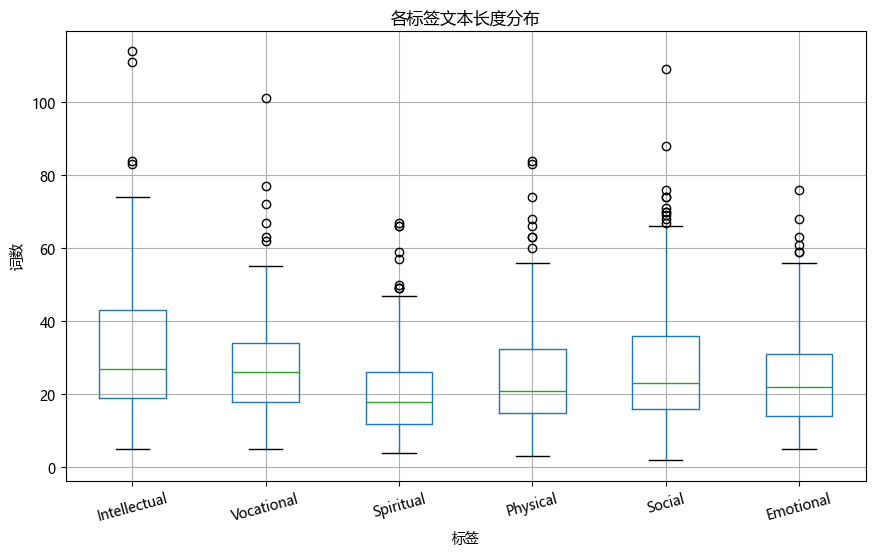

In [65]:
# 各标签的文本长度分布
df['text_length'] = df['text_cleaned'].apply(lambda x: len(x.split()))

# 按标签统计
length_stats = df.groupby('labels')['text_length'].agg(['mean', 'median', 'max', 'min'])
print(length_stats)

# 可视化
df.boxplot(column='text_length', by='labels', figsize=(10, 6))
plt.title('各标签文本长度分布')
plt.suptitle('')
plt.xlabel('标签')
plt.ylabel('词数')
ax = plt.gca()
ax.set_xticklabels(['Intellectual', 'Vocational', 'Spiritual',
                    'Physical', 'Social', 'Emotional'], rotation=15)
plt.savefig('charts/02_label_length.png', dpi=150, bbox_inches='tight')
plt.show()

In [66]:
# 每条文本用了多少不重复的词(丰富度）
df['unique_words'] = df['text_tokens'].apply(lambda x: len(set(x)))
df['vocab_richness'] = df['unique_words'] / df['text_length']

label_names = {0: 'Intellectual', 1: 'Vocational', 2: 'Spiritual',
               3: 'Physical', 4: 'Social', 5: 'Emotional'}

result = df.groupby('labels')[['text_length', 'unique_words', 'vocab_richness']].mean().round(2)
result.index = result.index.map(label_names)
result

,text_length,unique_words,vocab_richness
labels,,,
Intellectual,32.84,9.62,0.30
Vocational,28.12,9.00,0.33
Spiritual,20.86,5.83,0.29
Physical,24.89,8.95,0.38
Social,27.30,8.43,0.32
Emotional,24.24,7.19,0.31


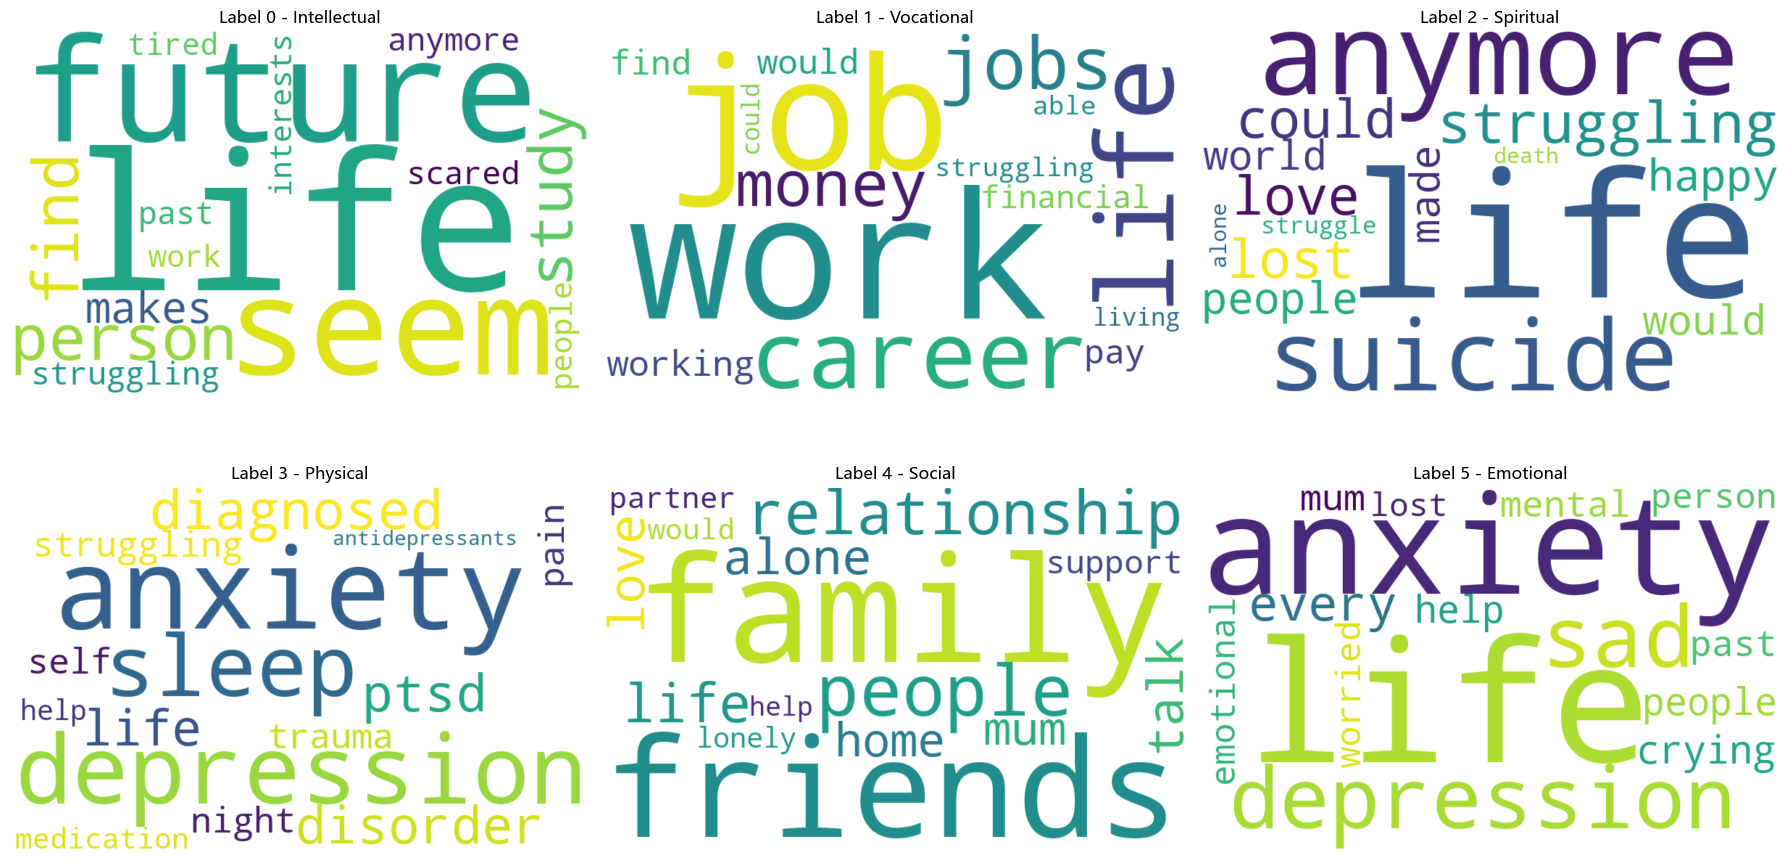

In [67]:
label_names = {0: 'Intellectual', 1: 'Vocational', 2: 'Spiritual',
               3: 'Physical', 4: 'Social', 5: 'Emotional'}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for label in range(6):
    if label in label_word_freq and label_word_freq[label]:
        wc = WordCloud(width=800, height=500,
                       background_color='white',
                       max_words=15,
                       colormap='viridis').generate_from_frequencies(label_word_freq[label])
        axes[label].imshow(wc, interpolation='bilinear')
        axes[label].set_title(f'Label {label} - {label_names[label]}', fontsize=12)
        axes[label].axis('off')

plt.tight_layout()
plt.savefig('charts/03_text_wordcloud_all.png', dpi=150, bbox_inches='tight')
plt.show()

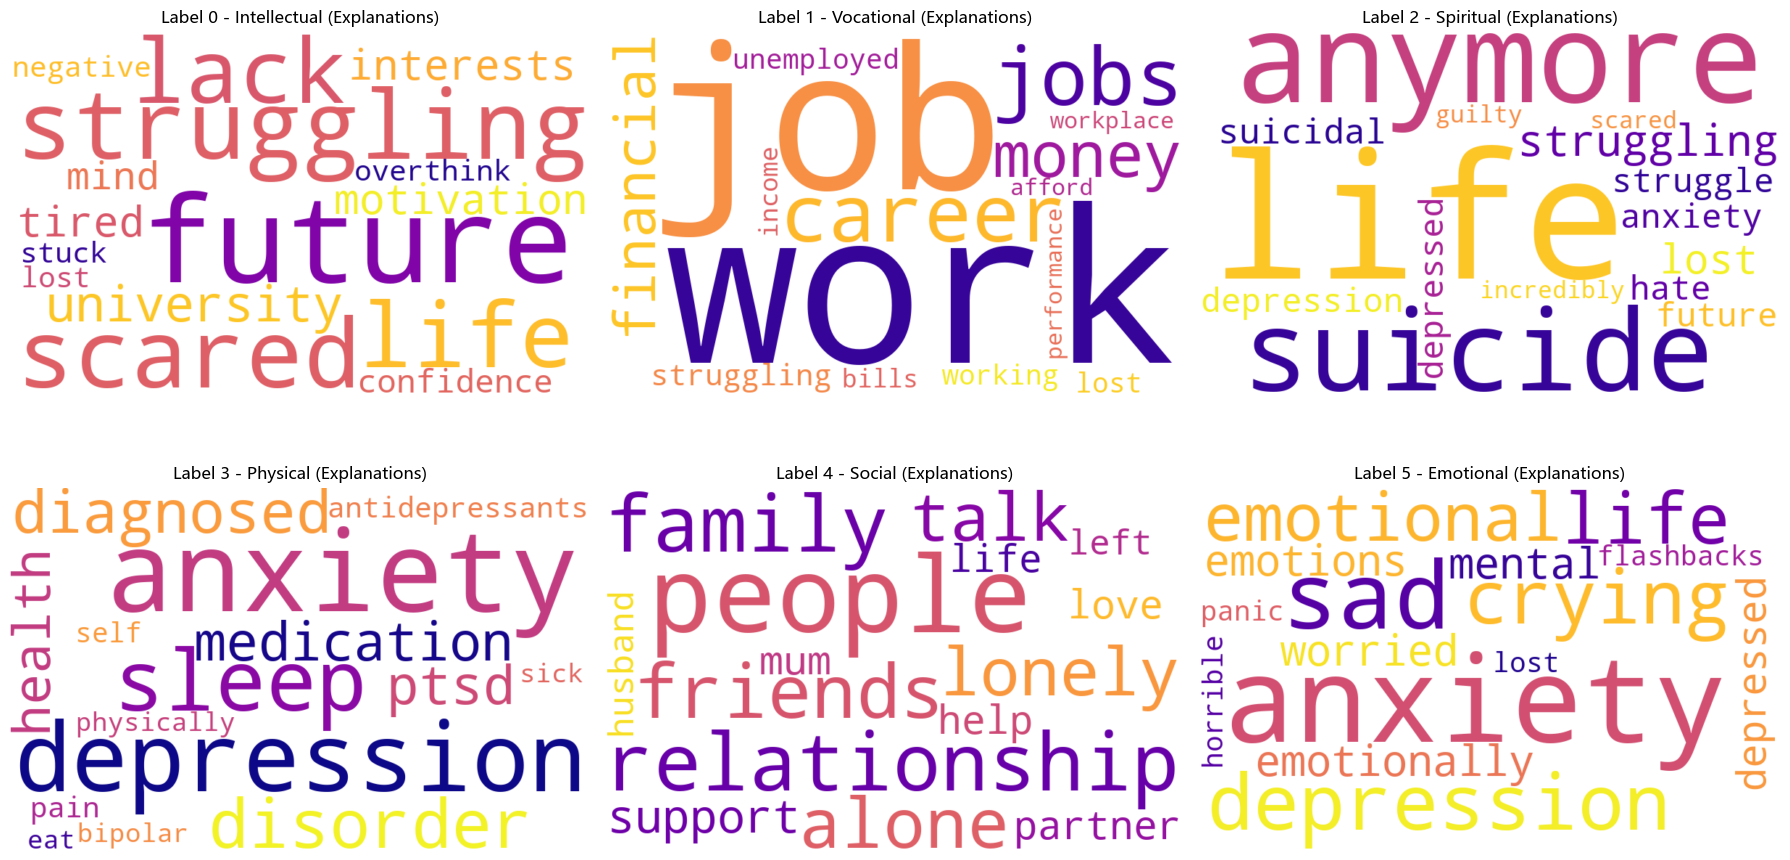

In [70]:
#exp词云图
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for label in range(6):
    if label in exp_label_word_freq and exp_label_word_freq[label]:
        wc = WordCloud(width=800, height=500,
                       background_color='white',
                       max_words=15,
                       colormap='plasma').generate_from_frequencies(exp_label_word_freq[label])
        axes[label].imshow(wc, interpolation='bilinear')
        axes[label].set_title(f'Label {label} - {label_names[label]} (Explanations)', fontsize=12)
        axes[label].axis('off')

plt.tight_layout()
plt.savefig('charts/04_exp_wordcloud_all.png', dpi=150, bbox_inches='tight')
plt.show()


### TFIDF向量化

In [58]:
# 文档级 TF-IDF（每条文本单独向量化，再按标签取均值）
vectorizer_doc = TfidfVectorizer(max_features=1000, stop_words='english')
tfidf_matrix = vectorizer_doc.fit_transform(df['text_cleaned'])
feature_names = vectorizer_doc.get_feature_names_out()

tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=feature_names)
tfidf_df['label'] = df['labels'].values

label_names = {0:'Intellectual', 1:'Vocational', 2:'Spiritual',               
3:'Physical', 4:'Social', 5:'Emotional'}
for label in sorted(df['labels'].unique()):
    top = (tfidf_df[tfidf_df['label'] == label]
           .drop('label', axis=1)
           .mean()
           .nlargest(15))
    print(f"\n=== 标签 {label}（{label_names[label]}）Top15 ===")
    for word, score in top.items():
        print(f"  {word}: {score:.4f}")


=== 标签 0（Intellectual）Top15 ===
  im: 0.0663
  feel: 0.0525
  like: 0.0487
  dont: 0.0478
  just: 0.0457
  know: 0.0325
  want: 0.0302
  hard: 0.0302
  life: 0.0251
  think: 0.0248
  try: 0.0246
  things: 0.0238
  future: 0.0231
  person: 0.0206
  feeling: 0.0205

=== 标签 1（Vocational）Top15 ===
  work: 0.0941
  job: 0.0825
  im: 0.0664
  dont: 0.0365
  like: 0.0359
  ive: 0.0329
  feel: 0.0305
  career: 0.0304
  just: 0.0266
  financial: 0.0258
  working: 0.0254
  jobs: 0.0246
  want: 0.0245
  things: 0.0229
  money: 0.0226

=== 标签 2（Spiritual）Top15 ===
  feel: 0.0703
  life: 0.0545
  im: 0.0536
  just: 0.0466
  dont: 0.0344
  like: 0.0320
  anymore: 0.0258
  ive: 0.0244
  really: 0.0229
  know: 0.0219
  suicide: 0.0217
  want: 0.0204
  time: 0.0187
  think: 0.0180
  thoughts: 0.0180

=== 标签 3（Physical）Top15 ===
  anxiety: 0.0478
  depression: 0.0415
  ive: 0.0413
  sleep: 0.0365
  im: 0.0301
  diagnosed: 0.0239
  years: 0.0217
  disorder: 0.0201
  antidepressants: 0.0195
  feel: 0.019

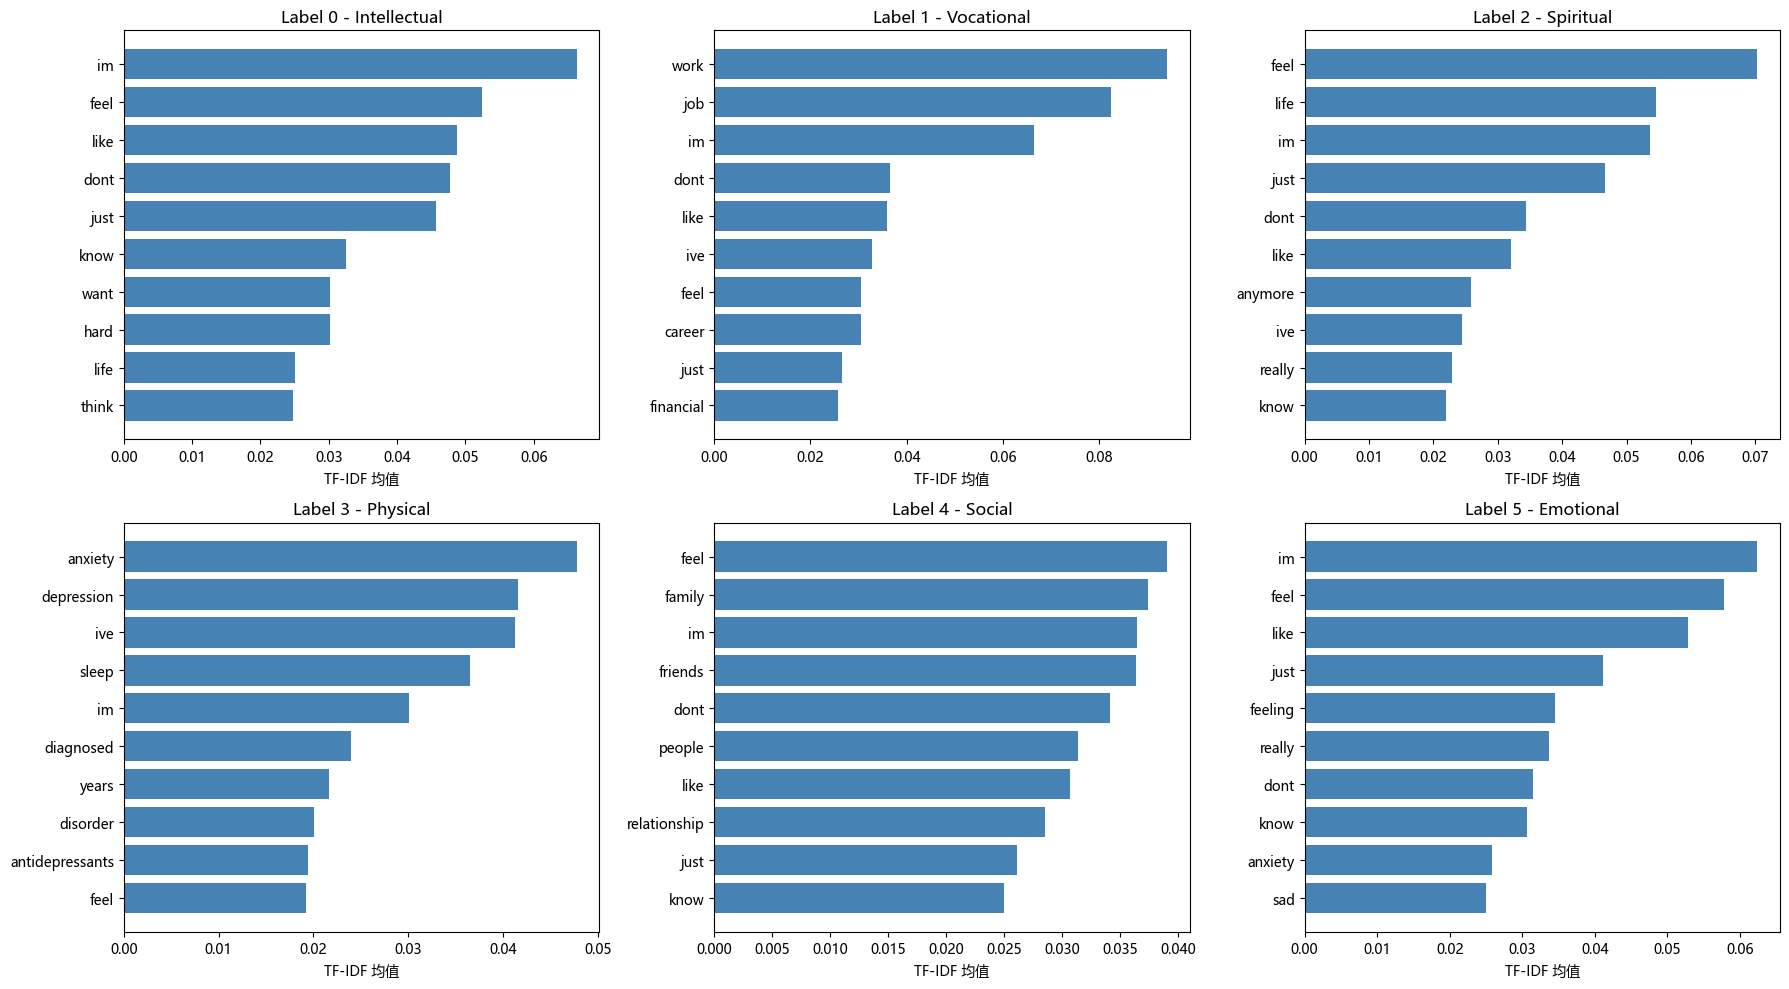

In [59]:
import matplotlib.pyplot as plt

label_names = {0:'Intellectual', 1:'Vocational', 2:'Spiritual',
               3:'Physical', 4:'Social', 5:'Emotional'}

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for label in range(6):
    top = (tfidf_df[tfidf_df['label'] == label]
           .drop('label', axis=1)
           .mean()
           .nlargest(10))
    axes[label].barh(top.index[::-1], top.values[::-1], color='steelblue')
    axes[label].set_title(f'Label {label} - {label_names[label]}', fontsize=12)
    axes[label].set_xlabel('TF-IDF 均值')

plt.tight_layout()
plt.savefig('charts/05_tfidf_all.png', dpi=150, bbox_inches='tight')
plt.show()

### 机器学习

In [60]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

# 用清洗后的文本，标签就是 df['labels']
X = df['text_cleaned']
y = df['labels']

# 8成训练，2成测试，random_state 保证每次结果一样
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 向量化（只在训练集上 fit，避免数据泄漏）
vectorizer = TfidfVectorizer(max_features=3000)
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print(f"训练集: {X_train_tfidf.shape}, 测试集: {X_test_tfidf.shape}")

训练集: (1129, 3000), 测试集: (283, 3000)


In [61]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 训练（max_iter 调大防止不收敛警告）
clf = LogisticRegression(max_iter=1000, random_state=42,class_weight='balanced')
clf.fit(X_train_tfidf, y_train)

# 预测 + 评估
y_pred = clf.predict(X_test_tfidf)
print(f"准确率: {accuracy_score(y_test, y_pred):.2%}")
print(classification_report(y_test, y_pred))

准确率: 55.48%
              precision    recall  f1-score   support

           0       0.41      0.45      0.43        31
           1       0.69      0.58      0.63        31
           2       0.33      0.41      0.37        29
           3       0.69      0.74      0.72        58
           4       0.68      0.65      0.67        83
           5       0.35      0.31      0.33        51

    accuracy                           0.55       283
   macro avg       0.53      0.53      0.52       283
weighted avg       0.56      0.55      0.56       283



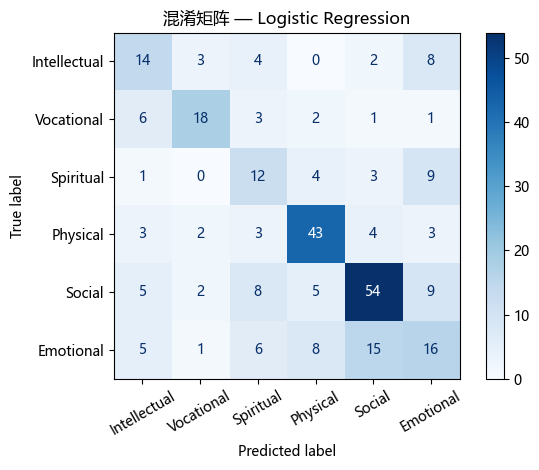

In [71]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

label_names = ['Intellectual', 'Vocational', 'Spiritual',
               'Physical', 'Social', 'Emotional']

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=label_names,
    cmap='Blues'
)
plt.title('混淆矩阵 — Logistic Regression')
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig('charts/06_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()